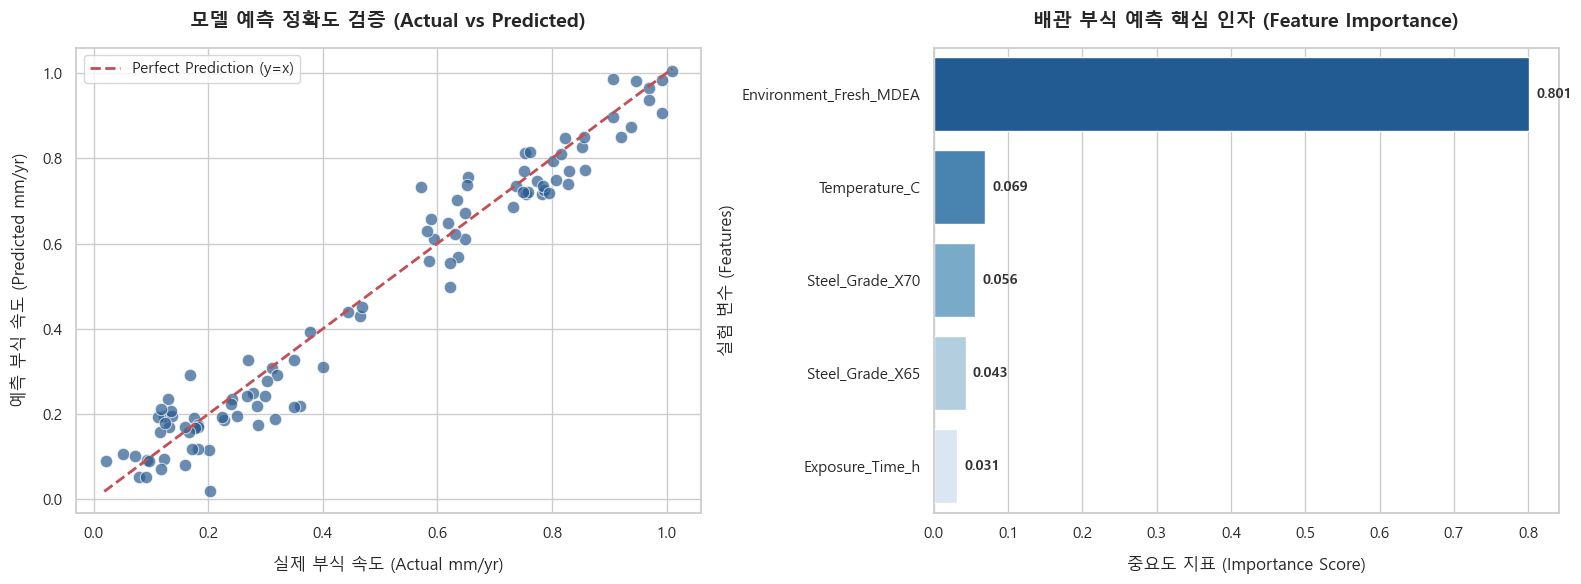

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# [참고] 분석에 지장을 주지 않는 일반 경고 메시지는 무시하도록 설정
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ==========================================
# [1단계] 머신러닝용 데이터 세팅 & 학습
# ==========================================
np.random.seed(42)
n_samples = 500

mock_data = {
    "Steel_Grade": np.random.choice(["X65", "X70", "A414"], n_samples),
    "Environment": np.random.choice(["Fresh_MDEA", "Aged_MDEA"], n_samples),
    "Temperature_C": np.random.choice([25, 50, 80], n_samples),
    "Exposure_Time_h": np.random.randint(24, 720, n_samples),
}
df_ml = pd.DataFrame(mock_data)
df_ml["Corrosion_Rate_mm_yr"] = (
    (df_ml["Environment"] == "Aged_MDEA").astype(int) * 0.5
    + (df_ml["Temperature_C"] / 100) * 0.3
    + (df_ml["Steel_Grade"] == "A414").astype(int) * 0.2
    + np.random.normal(0, 0.05, n_samples)
)
df_ml["Corrosion_Rate_mm_yr"] = df_ml["Corrosion_Rate_mm_yr"].clip(lower=0.001)

df_encoded = pd.get_dummies(df_ml, columns=["Steel_Grade", "Environment"], drop_first=True)

X = df_encoded.drop(columns=["Corrosion_Rate_mm_yr"])
y = df_ml["Corrosion_Rate_mm_yr"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

importances = model.feature_importances_
df_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# ==========================================
# [2단계] 주피터 노트북 시각화 및 폰트 강제 지정
# ==========================================
# 윈도우 환경에서 가장 확실하게 작동하는 한글 폰트 설정 구조로 변경
plt.rc("font", family="Malgun Gothic") 
plt.rc("axes", unicode_minus=False)

# 기본 테마를 설정하되 폰트는 방금 지정한 맑은고딕이 유지되도록 설정
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
# [3단계] 그래프 그리기 (최신 문법 반영)
# ==========================================
# Graph 1: Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color="#2b5c8f", edgecolor="w", s=80, ax=axes[0])
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Perfect Prediction (y=x)")
axes[0].set_title("모델 예측 정확도 검증 (Actual vs Predicted)", fontsize=14, fontweight="bold", pad=15)
axes[0].set_xlabel("실제 부식 속도 (Actual mm/yr)", fontsize=12, labelpad=10)
axes[0].set_ylabel("예측 부식 속도 (Predicted mm/yr)", fontsize=12, labelpad=10)
axes[0].legend(loc="upper left")

# Graph 2: Feature Importance (hue 관련 경고 해결 문법 적용)
sns.barplot(
    x=df_importance.values, 
    y=df_importance.index, 
    hue=df_importance.index, # 경고 해결을 위해 세로축 변수를 hue에 바인딩
    palette="Blues_r", 
    legend=False,            # 범례는 중복되므로 끄기
    ax=axes[1]
)
axes[1].set_title("배관 부식 예측 핵심 인자 (Feature Importance)", fontsize=14, fontweight="bold", pad=15)
axes[1].set_xlabel("중요도 지표 (Importance Score)", fontsize=12, labelpad=10)
axes[1].set_ylabel("실험 변수 (Features)", fontsize=12)

for i, v in enumerate(df_importance.values):
    axes[1].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=10, fontweight="bold", color="#333333")

plt.tight_layout()
plt.show()